# Power Law Distribution — Demo

This notebook demonstrates:

- Power-law relationships
- Heavy-tailed behavior
- Log-log visualization
- Pareto-like data
- Box-Cox transformation
- Q-Q Plot

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## 1. Generate Power Law Data

We use the relationship:

y = Cx^(-α)

where:

- C = constant
- α = power-law exponent

In [2]:
x = np.arange(1, 101)

C = 1000
alpha = 1.5

y = C * x ** (-alpha)

print("First 10 values:")
print(y[:10])

First 10 values:
[1000.          353.55339059  192.45008973  125.           89.4427191
   68.04138174   53.99492472   44.19417382   37.03703704   31.6227766 ]


## 2. Visualize the Power Law

The distribution decreases rapidly at first and then develops a long tail.

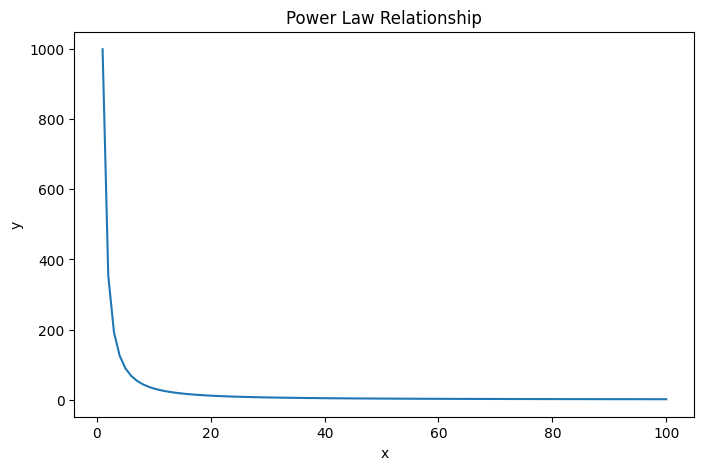

In [3]:
plt.figure(figsize=(8, 5))

plt.plot(x, y)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Power Law Relationship")

plt.show()

## 3. Log-Log Plot

Taking logarithms:

ln(y) = ln(C) - α ln(x)

Therefore, a power-law relationship appears approximately linear on a
log-log plot.

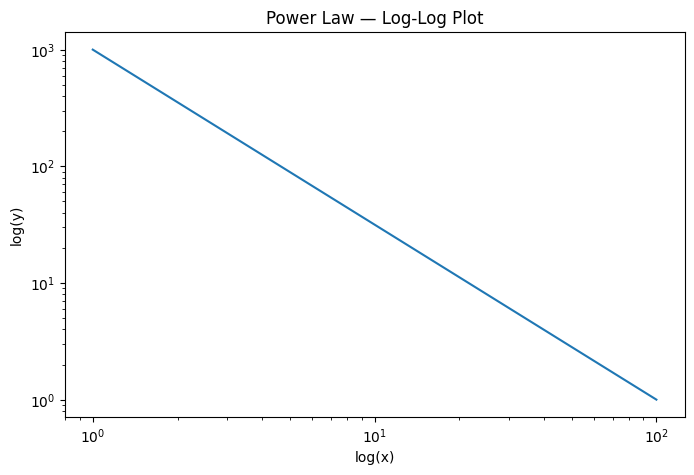

In [4]:
plt.figure(figsize=(8, 5))

plt.loglog(x, y)

plt.xlabel("log(x)")
plt.ylabel("log(y)")
plt.title("Power Law — Log-Log Plot")

plt.show()

## 4. Estimate the Power-Law Exponent

We can fit a straight line to the logarithm of the data.

log(y) = intercept + slope × log(x)

For a power law:

slope ≈ -α

In [5]:
log_x = np.log(x)
log_y = np.log(y)

slope, intercept, r_value, p_value, std_err = stats.linregress(
    log_x,
    log_y
)

estimated_alpha = -slope

print(f"Estimated exponent α: {estimated_alpha:.3f}")
print(f"R²: {r_value**2:.4f}")

Estimated exponent α: 1.500
R²: 1.0000


## 5. Pareto-Like Data

A Pareto distribution is a classic example of a heavy-tailed distribution.

We generate random samples from a Pareto distribution and visualize them.

In [6]:
np.random.seed(42)

sample = stats.pareto.rvs(
    b=2.5,
    size=10000
)

print("Minimum:", sample.min())
print("Maximum:", sample.max())
print("Mean:", sample.mean())

Minimum: 1.0000046539400498
Maximum: 26.28446917599533
Mean: 1.6359954254778153


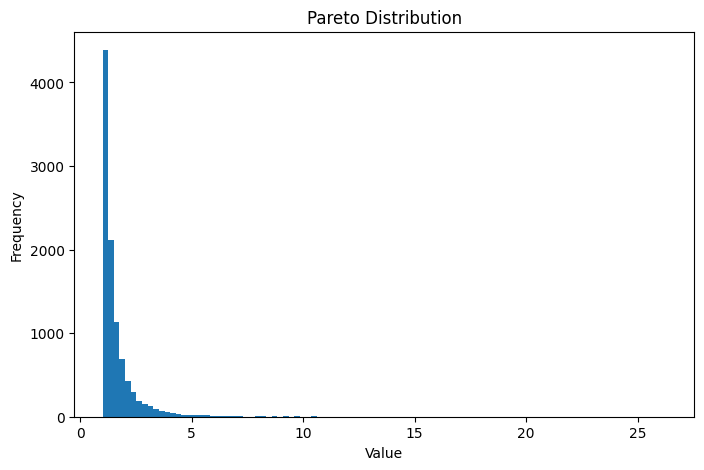

In [7]:
plt.figure(figsize=(8, 5))

plt.hist(sample, bins=100)

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Pareto Distribution")

plt.show()

## 6. Log Transformation

Highly right-skewed data can sometimes become more symmetric after applying
a logarithmic transformation.

Here we compare the original data with its logarithm.

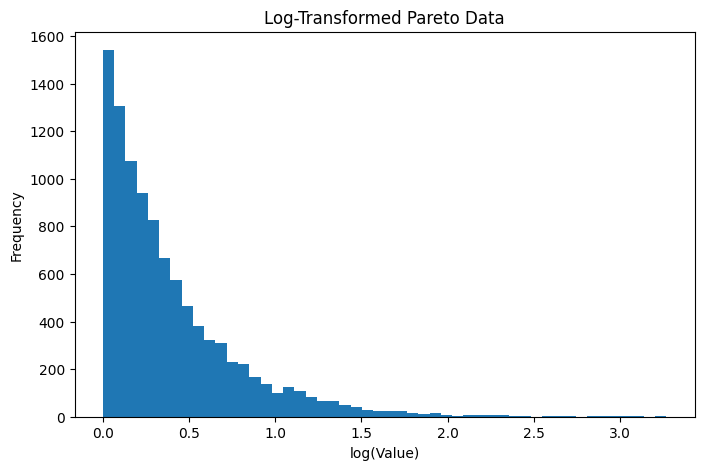

In [8]:
log_sample = np.log(sample)

plt.figure(figsize=(8, 5))

plt.hist(log_sample, bins=50)

plt.xlabel("log(Value)")
plt.ylabel("Frequency")
plt.title("Log-Transformed Pareto Data")

plt.show()

## 7. Box-Cox Transformation

The Box-Cox transformation can be used with positive-valued data to reduce
skewness and make the distribution more approximately Normal.

The transformation is:

x(λ) = (x^λ - 1) / λ

for λ ≠ 0.

When λ = 0:

x(λ) = ln(x)

In [9]:
transformed, lambda_value = stats.boxcox(sample)

print(f"Optimal Box-Cox λ: {lambda_value:.4f}")

Optimal Box-Cox λ: -1.8180


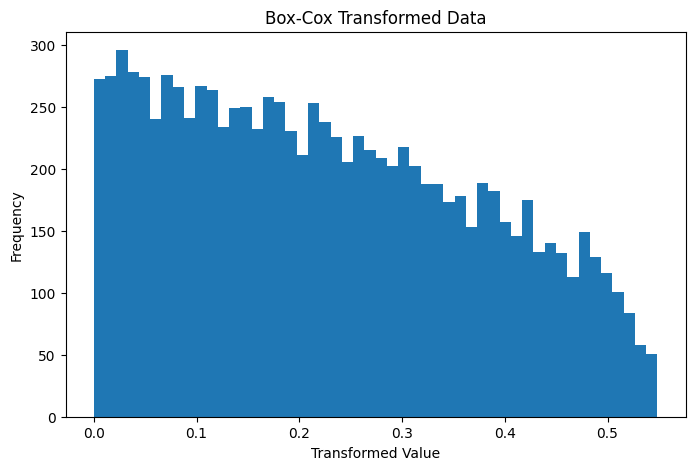

In [10]:
plt.figure(figsize=(8, 5))

plt.hist(transformed, bins=50)

plt.xlabel("Transformed Value")
plt.ylabel("Frequency")
plt.title("Box-Cox Transformed Data")

plt.show()

## 8. Q-Q Plot

A Q-Q Plot can be used to check whether transformed data is approximately
Normal.

If the points approximately follow a straight line, the data is reasonably
close to a Normal Distribution.

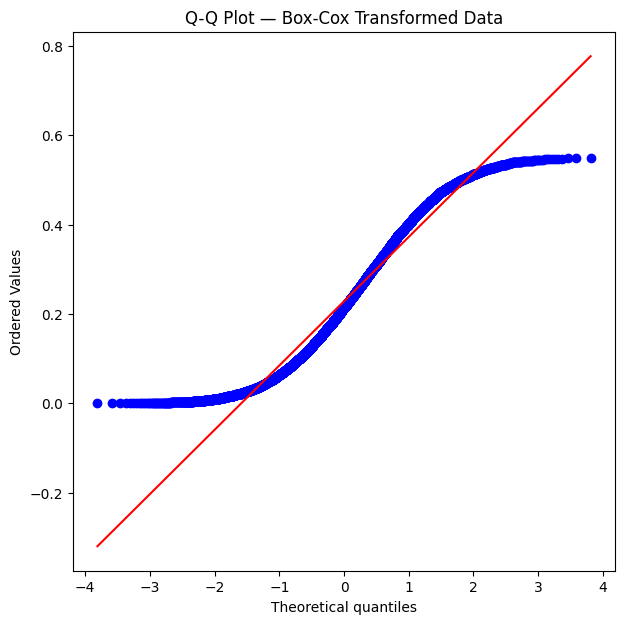

In [11]:
plt.figure(figsize=(7, 7))

stats.probplot(
    transformed,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot — Box-Cox Transformed Data")

plt.show()

## 9. Compare Original and Transformed Data

### Original Data

- Strong right skew
- Heavy tail
- Large extreme values

### Transformed Data

- Reduced skewness
- More symmetric
- Can be closer to Normal

> Transformation does not mean that every power-law dataset becomes Normal.
> It depends on the underlying data and the transformation used.

## Key Takeaways

- Power-law relationships can be represented as `y = Cx^(-α)`.
- Power-law data often has a long tail.
- Log-log plots are useful for investigating power-law relationships.
- Pareto distributions are an important example of heavy-tailed behavior.
- The 80/20 Rule is associated with Pareto-type behavior.
- Box-Cox transformation can reduce skewness in suitable positive-valued data.
- Q-Q plots can be used to assess approximate Normality after transformation.